# 01 — Exploring LMC and Milky Way star data

The Large Magellanic Cloud (LMC) is a satellite galaxy of the Milky Way, about 160,000
light-years away. When Gaia looks toward it, it sees two populations mixed together on the
same patch of sky:

- **LMC stars** — real members of that distant galaxy.
- **Milky Way foreground stars** — nearby stars in *our own* galaxy that happen to sit in
  the line of sight, in front of the LMC.

Data → `../data/LMC+MW_GOG_trainingset_frac=0.2.csv`

Every row is a star. The last column, `Type`, is the answer key from a physics simulation
(the Gaia Object Generator):

- **Type = 1** → a real LMC star (distant satellite galaxy, ~160,000 light-years away)
- **Type = 0** → a Milky Way foreground star (nearby, in our own galaxy, in the line of sight)

**The job of this notebook is not to model anything.** It is to check whether the physics
that should separate the two populations is actually *visible* in the data. If it is,
notebook 02's classifier is justified. If it isn't, we stop and rethink.

## 0. Load — 

Read the file and look at one column before doing anything else.

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

DATASET = "../data/LMC+MW_GOG_trainingset_frac=0.2.csv"
raw = pl.read_csv(DATASET)

print(raw["pmra"])

shape: (1_269_705,)
Series: 'pmra' [str]
[
	"1.822807103781843"
	"1.848487240291031"
	"1.95246368716238"
	"1.5478615751002112"
	"1.392517243474222"
	…
	"9.805264710055294"
	"-7.525910336338684"
	"0.18397489966962"
	"2.246842877849963"
	"2.4494045147758268"
]


### That column is text.

`pmra` is proper motion — the single most important physical quantity in this dataset — and
Polars typed it as `str`, not `f64`.

One value is corrupt:

```
pmra = "1.8598455n11059828"
```

A stray `n` where an `e` or `-` belongs. One bad character in 1.27 million rows is enough to
force the entire column to string, and a string column silently breaks every calculation and
every plot that touches it. Nothing errors — you just get the wrong answer.

**The fix:** cast every column except the label to `Float64` non-strictly (unparseable values
become null), then drop the nulls. We print how many rows we lost, because a silent fix is
indistinguishable from no bug at all.

In [2]:
num_cols = [c for c in raw.columns if c != "Type"]
df = raw.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in num_cols])

before = df.height
df = df.drop_nulls(subset=num_cols)
dropped = before - df.height

print(f"dropped {dropped} corrupted row(s)  ->  {df.height:,} clean rows remain")
print("dtypes now:", sorted({str(d) for d in df.dtypes}))

dropped 1 corrupted row(s)  ->  1,269,704 clean rows remain
dtypes now: ['Float64', 'Int64']


## 1. Shape and columns

What are we actually working with, and what does each column mean physically?

In [3]:
MEANING = {
    "ra":                "Right ascension — sky longitude (deg)",
    "dec":               "Declination — sky latitude (deg)",
    "pmra":              "Proper motion east–west (mas/yr)",
    "pmra_error":        "Uncertainty on pmra (mas/yr)",
    "pmdec":             "Proper motion north–south (mas/yr)",
    "pmdec_error":       "Uncertainty on pmdec (mas/yr)",
    "phot_g_mean_mag":   "G-band magnitude — broad-band brightness",
    "phot_bp_mean_mag":  "BP magnitude — blue band",
    "phot_rp_mean_mag":  "RP magnitude — red band",
    "parallax":          "Parallax (mas) — 1/parallax = distance in kpc",
    "parallax_error":    "Uncertainty on parallax (mas)",
    "Type":              "LABEL — 1 = LMC member, 0 = Milky Way foreground",
}

print(f"shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
for c in df.columns:
    print(f"  {c:<18} {str(df[c].dtype):<8} {MEANING[c]}")

shape: 1,269,704 rows x 12 columns

  ra                 Float64  Right ascension — sky longitude (deg)
  dec                Float64  Declination — sky latitude (deg)
  pmra               Float64  Proper motion east–west (mas/yr)
  pmra_error         Float64  Uncertainty on pmra (mas/yr)
  pmdec              Float64  Proper motion north–south (mas/yr)
  pmdec_error        Float64  Uncertainty on pmdec (mas/yr)
  phot_g_mean_mag    Float64  G-band magnitude — broad-band brightness
  phot_bp_mean_mag   Float64  BP magnitude — blue band
  phot_rp_mean_mag   Float64  RP magnitude — red band
  parallax           Float64  Parallax (mas) — 1/parallax = distance in kpc
  parallax_error     Float64  Uncertainty on parallax (mas)
  Type               Int64    LABEL — 1 = LMC member, 0 = Milky Way foreground


## 2. Label balance

How lopsided are the classes? This decides how we have to read every score later.

In [4]:
counts = df["Type"].value_counts().sort("Type")
n = df.height
for row in counts.iter_rows(named=True):
    name = "LMC" if row["Type"] == 1 else "Milky Way"
    print(f"  Type {row['Type']}  {name:<10} {row['count']:>9,}   {100*row['count']/n:5.2f}%")

lmc_frac = float((df["Type"] == 1).mean())
print(f"\nimbalance ratio (MW : LMC) = {(1-lmc_frac)/lmc_frac:.2f} : 1")
print(f"a model that always guesses 'Milky Way' scores {100*(1-lmc_frac):.1f}% accuracy "
      f"and catches zero LMC stars.")

  Type 0  Milky Way    992,527   78.17%
  Type 1  LMC          277,177   21.83%

imbalance ratio (MW : LMC) = 3.58 : 1
a model that always guesses 'Milky Way' scores 78.2% accuracy and catches zero LMC stars.


That last line is the reason accuracy is a useless metric here, and the reason notebook 02
sets `scale_pos_weight` instead of hoping for the best.

## 3. Summary statistics

Not to admire — to build a feel for what "normal" looks like, so an outlier later is obvious.

Three things to read for:

- **parallax** — mean should sit near 0. The LMC is far enough that its parallax is
  unmeasurable, so it piles up at zero (and scatters negative, which is physically
  impossible but statistically expected from noise).
- **proper motion** — the errors should be much smaller than the values themselves,
  otherwise the signal is buried.
- **magnitudes** — should fall in a believable Gaia band, roughly 10–21.

In [5]:
with pl.Config(tbl_cols=-1, float_precision=3, tbl_width_chars=200):
    display(df.select([c for c in df.columns if c != "Type"]).describe())

statistic,ra,dec,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,parallax,parallax_error
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",1269704.000,1269704.000,1269704.000,1269704.000,1269704.000,1269704.000,1269704.000,1269704.000,1269704.000,1269704.000,1269704.000
"""null_count""",0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
"""mean""",88.228,-69.311,1.861,0.225,4.783,0.201,18.297,18.857,17.606,0.613,0.405
"""std""",21.305,6.453,7.604,0.227,9.635,0.203,1.700,1.811,1.666,1.021,0.409
"""min""",32.064,-84.956,-495.724,0.028,-1216.825,0.025,5.719,5.800,4.327,-10.419,0.050
"""25%""",75.428,-73.279,-1.134,0.066,0.370,0.059,17.482,17.965,16.800,0.096,0.119
"""50%""",86.245,-69.302,1.780,0.160,3.256,0.143,18.763,19.272,18.054,0.470,0.288
"""75%""",105.234,-65.251,3.657,0.306,7.983,0.273,19.547,20.107,18.808,0.955,0.550
"""max""",130.518,-54.605,864.433,3.675,1335.263,3.278,21.014,23.913,22.145,127.906,6.610


## 4. Missing values

Now — *after* the cast — the data can honestly be called clean.

In [6]:
nulls = {c: int(df[c].null_count()) for c in df.columns}
total = sum(nulls.values())
print(f"total nulls across all columns: {total}")
if total:
    for c, k in nulls.items():
        if k:
            print(f"  {c}: {k}")

total nulls across all columns: 0


Zero — but that clean bill of health is *earned* by step 0, not free. On the raw load the
same check also reports zero, because the corrupt value hid inside a string column. The
check only means something after the coercion.

## 5. The key plot — proper motion

**The question:** does the LMC move as one coherent blob?

It should. Every star in the LMC is bound to the same galaxy, and that galaxy is moving
across our sky as a single body. Milky Way foreground stars share no such motion — they are
at all distances, on all orbits, drifting every which way.

1.27M points is unreadable and slow, so we draw a seeded 60k sample and reuse that same
sample for every scatter from here on.

In [7]:
rng = np.random.default_rng(0)
SAMPLE_N = 60_000
sample_idx = rng.choice(df.height, size=SAMPLE_N, replace=False)

s = df[sample_idx]
is_lmc = (s["Type"] == 1).to_numpy()
print(f"sample: {SAMPLE_N:,} stars  ({is_lmc.sum():,} LMC / {(~is_lmc).sum():,} Milky Way)")

MW_C, LMC_C = "#9aa0a6", "#ff8c42"

sample: 60,000 stars  (13,051 LMC / 46,949 Milky Way)


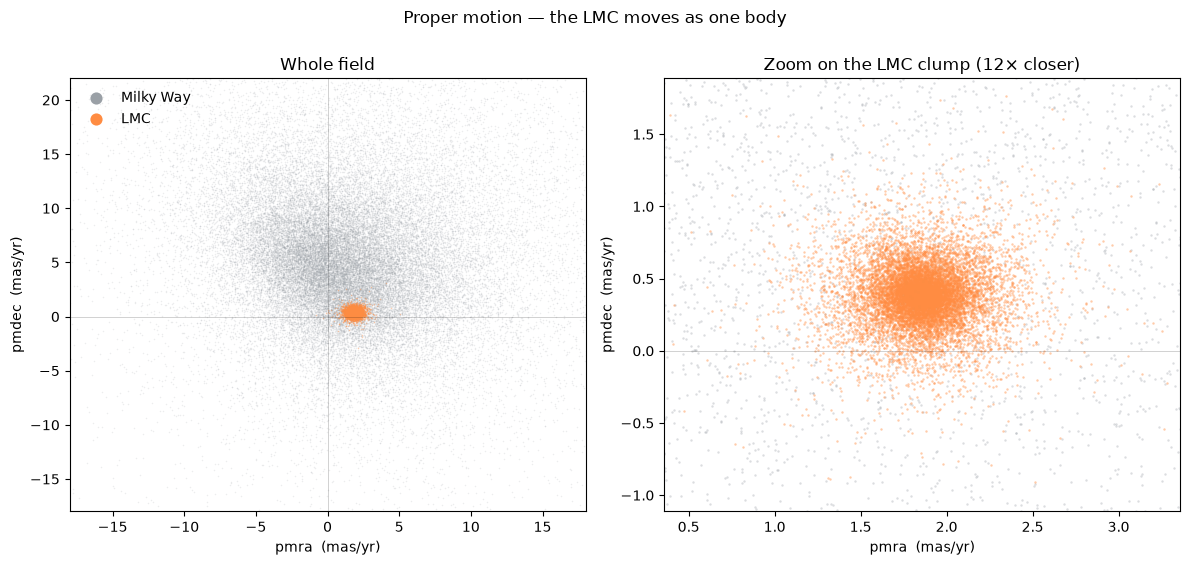

In [8]:
pmra, pmdec = s["pmra"].to_numpy(), s["pmdec"].to_numpy()
cx, cy = np.median(pmra[is_lmc]), np.median(pmdec[is_lmc])

fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))

# Left: the whole field, wide enough to actually contain the Milky Way's spread.
ax = axes[0]
ax.scatter(pmra[~is_lmc], pmdec[~is_lmc], s=1.2, c=MW_C, alpha=0.18, lw=0, label="Milky Way")
ax.scatter(pmra[is_lmc],  pmdec[is_lmc],  s=1.2, c=LMC_C, alpha=0.40, lw=0, label="LMC")
ax.set_xlim(-18, 18); ax.set_ylim(-18, 22)
ax.set_title("Whole field")
leg = ax.legend(markerscale=8, frameon=False, loc="upper left")
for h in leg.legend_handles:
    h.set_alpha(1)

# Right: the same data, zoomed onto the LMC clump. Note the axis span: 3 mas/yr
# against 36 on the left.
ax = axes[1]
ax.scatter(pmra[~is_lmc], pmdec[~is_lmc], s=3.0, c=MW_C, alpha=0.35, lw=0)
ax.scatter(pmra[is_lmc],  pmdec[is_lmc],  s=3.0, c=LMC_C, alpha=0.45, lw=0)
ax.set_xlim(cx - 1.5, cx + 1.5); ax.set_ylim(cy - 1.5, cy + 1.5)
ax.set_title("Zoom on the LMC clump (12× closer)")

for ax in axes:
    ax.set_xlabel("pmra  (mas/yr)"); ax.set_ylabel("pmdec  (mas/yr)")
    ax.axhline(0, lw=0.5, c="k", alpha=0.25); ax.axvline(0, lw=0.5, c="k", alpha=0.25)

fig.suptitle("Proper motion — the LMC moves as one body", y=1.00)
plt.tight_layout(); plt.show()

In [9]:
# Quantify what the eye just saw. Median and IQR, not mean and standard deviation:
# the Milky Way distribution has heavy tails that drag a mean around, and we want to
# describe where the bulk of each population sits.
for name, mask in (("LMC", is_lmc), ("Milky Way", ~is_lmc)):
    a, d = pmra[mask], pmdec[mask]
    iqr = lambda v: np.subtract(*np.percentile(v, [75, 25]))
    print(f"{name:<10} median = ({np.median(a):+.3f}, {np.median(d):+.3f}) mas/yr    "
          f"IQR = ({iqr(a):.3f}, {iqr(d):.3f})")

sep = np.hypot(np.median(pmra[is_lmc]) - np.median(pmra[~is_lmc]),
               np.median(pmdec[is_lmc]) - np.median(pmdec[~is_lmc]))
width = np.hypot(*[np.subtract(*np.percentile(v[is_lmc], [75, 25])) for v in (pmra, pmdec)])
print(f"\nseparation between the two centres: {sep:.2f} mas/yr")
print(f"width of the LMC clump (IQR):        {width:.2f} mas/yr")
print(f"the populations are {sep/width:.0f}x further apart than the LMC clump is wide")

LMC        median = (+1.857, +0.387) mas/yr    IQR = (0.225, 0.209)
Milky Way  median = (+1.117, +5.209) mas/yr    IQR = (7.039, 7.997)

separation between the two centres: 4.88 mas/yr
width of the LMC clump (IQR):        0.31 mas/yr
the populations are 16x further apart than the LMC clump is wide


**Seen — with one correction to the naive expectation.**

The LMC is a tight clump, about 0.3 mas/yr across, exactly as a gravitationally bound
population sharing one bulk motion should be. The Milky Way foreground is roughly 30× wider.
The two centres are separated by many times the clump's own width, which is why this
single view carries most of the classifying power in the dataset.

But the foreground is **not** centred on zero — its median sits near (+1.1, +5.2) mas/yr.
That is not an error. Nearby stars show the reflected motion of the Sun's own travel through
the Galaxy, projected onto this line of sight, so the foreground has a systematic drift of
its own. "LMC = small proper motion" would have been the wrong rule; the right one is
"LMC = *this particular* proper motion, tightly held." A tree model finds that box easily,
which is why proper motion dominates the importances in notebook 02.

## 6. Parallax — is the LMC "far" the way physics predicts?

Parallax is the apparent annual wobble of a star caused by Earth's orbit; it falls off as
1/distance. At the LMC's 50 kpc the true parallax is ~0.02 mas, far below Gaia's per-star
precision here. So the honest expectation is *not* "LMC parallax is small" — it is
**"LMC parallax is noise centred on zero, including impossible negative values."**

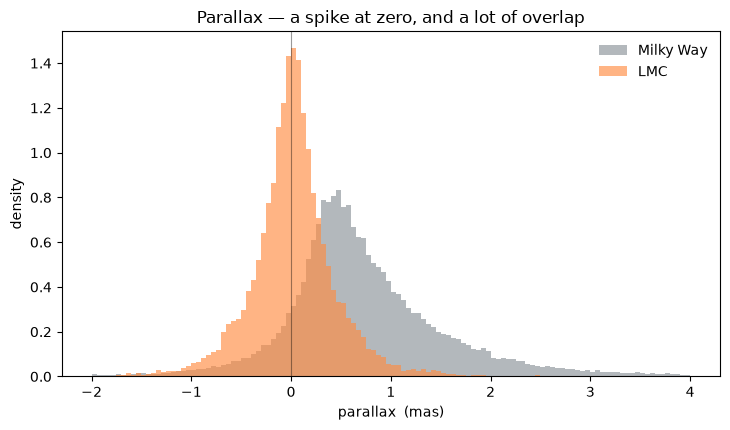

LMC stars with NEGATIVE measured parallax: 47.4%  (physically impossible — this is measurement noise, as expected)
median parallax_error for LMC stars: 0.344 mas


In [10]:
plx = s["parallax"].to_numpy()
bins = np.linspace(-2, 4, 121)

fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.hist(plx[~is_lmc], bins=bins, density=True, color=MW_C, alpha=0.75, label="Milky Way")
ax.hist(plx[is_lmc],  bins=bins, density=True, color=LMC_C, alpha=0.65, label="LMC")
ax.axvline(0, lw=0.8, c="k", alpha=0.4)
ax.set_xlabel("parallax  (mas)"); ax.set_ylabel("density")
ax.set_title("Parallax — a spike at zero, and a lot of overlap")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

neg = 100 * (plx[is_lmc] < 0).mean()
print(f"LMC stars with NEGATIVE measured parallax: {neg:.1f}%  "
      "(physically impossible — this is measurement noise, as expected)")
print(f"median parallax_error for LMC stars: {np.median(s['parallax_error'].to_numpy()[is_lmc]):.3f} mas")

**Seen.** The LMC spikes at zero as predicted — but the Milky Way distribution sits right on
top of it, because most foreground stars here are also distant enough to have small parallax.
Roughly half the LMC stars measure *negative* parallax, which is noise, not physics.

So parallax is a **weak** separator, and we should expect it to score low in feature
importance later. Knowing that now means the result won't look like a bug when it appears.

## 7. Colour–magnitude diagram

Do the two populations trace different stellar sequences?

`bp_rp = BP − RP` is blue minus red — a temperature proxy (bigger = redder = cooler). Plotted
against G magnitude this is the observational Hertzsprung–Russell diagram. Magnitudes run
backwards, so the y-axis is inverted: bright at the top.

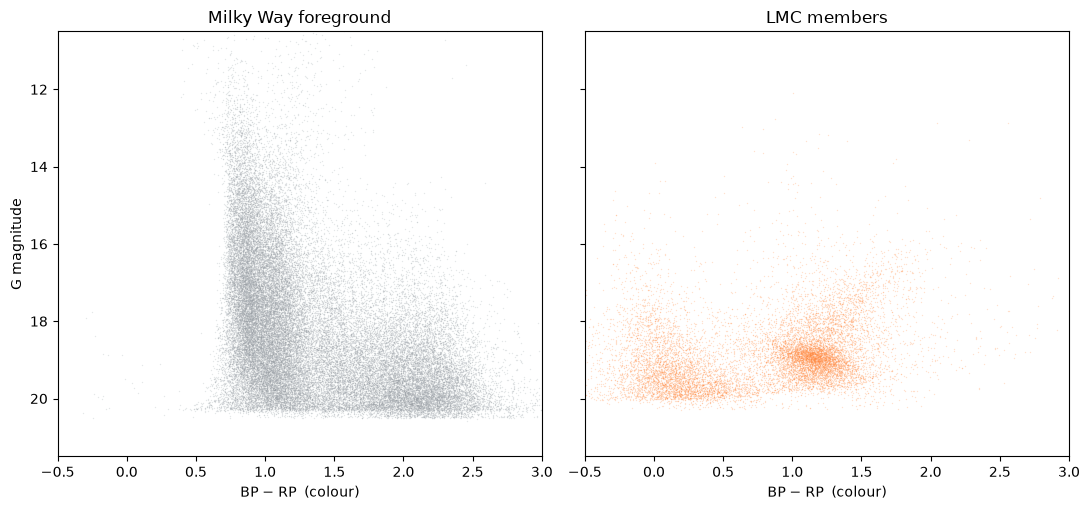

In [11]:
bp_rp = (s["phot_bp_mean_mag"] - s["phot_rp_mean_mag"]).to_numpy()
gmag = s["phot_g_mean_mag"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2), sharex=True, sharey=True)
for ax, (name, mask, colour) in zip(
    axes, (("Milky Way foreground", ~is_lmc, MW_C), ("LMC members", is_lmc, LMC_C))
):
    ax.scatter(bp_rp[mask], gmag[mask], s=1.0, c=colour, alpha=0.25, lw=0)
    ax.set_title(name)
    ax.set_xlabel("BP − RP  (colour)")
axes[0].set_ylabel("G magnitude")
axes[0].set_xlim(-0.5, 3.0); axes[0].set_ylim(21.5, 10.5)
plt.tight_layout(); plt.show()

**Seen.** Different structures. The Milky Way panel shows the broad foreground main sequence
spread over a wide range of brightness — these stars are at every distance, so identical
stars land at different magnitudes. The LMC panel is compressed: every member is at
essentially the same distance, so apparent magnitude tracks *true* luminosity and the
population's own sequences (main sequence, red clump, giant branch) survive as visible
structure.

Real signal, weaker than motion, worth keeping.

## 8. On-sky map — and the feature we are deliberately throwing away

Is the LMC concentrated on the sky? Obviously yes: it is a galaxy, it occupies a patch.

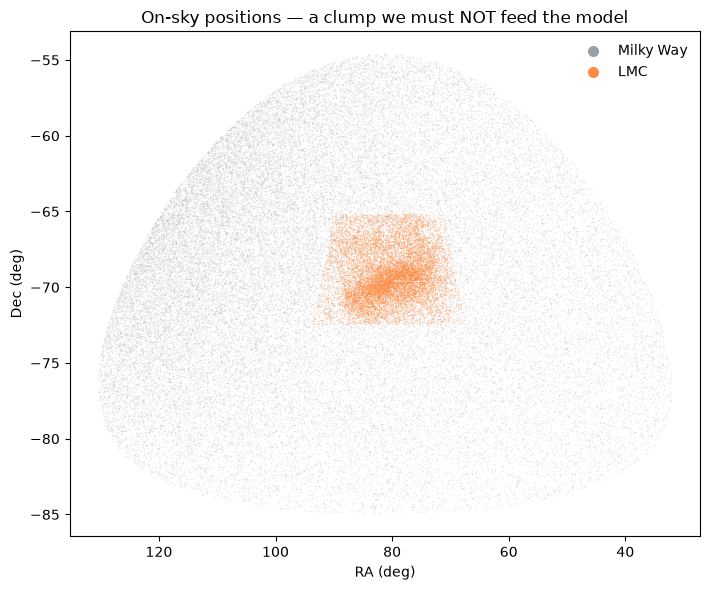

In [12]:
ra, dec = s["ra"].to_numpy(), s["dec"].to_numpy()

fig, ax = plt.subplots(figsize=(7.2, 6.0))
ax.scatter(ra[~is_lmc], dec[~is_lmc], s=1.0, c=MW_C, alpha=0.18, lw=0, label="Milky Way")
ax.scatter(ra[is_lmc],  dec[is_lmc],  s=1.0, c=LMC_C, alpha=0.30, lw=0, label="LMC")
ax.set_xlabel("RA (deg)"); ax.set_ylabel("Dec (deg)")
ax.set_title("On-sky positions — a clump we must NOT feed the model")
ax.invert_xaxis()
leg = ax.legend(markerscale=8, frameon=False, loc="upper right")
for h in leg.legend_handles:
    h.set_alpha(1)
plt.tight_layout(); plt.show()

**This plot is a warning, not a feature.**

If we hand `ra`/`dec` to a classifier it will memorise *"this sky box = LMC"* and score
beautifully on this dataset while learning no physics at all. Such a model:

- misses real LMC members in the sparse outskirts, outside the box it memorised;
- wrongly claims Milky Way stars that happen to sit in the middle of the field;
- cannot be pointed at any other part of the sky.

We looked, we noted the concentration, and we leave `ra` and `dec` **out of the feature set**.
Position is how we *display* the result in the end — never how we decide it.

## 9. What we actually saw

- **1.27M rows, 12 columns, clean — after fixing exactly one corrupted `pmra` value.** The
  corruption mattered far beyond its one row: it retyped the whole column to text.
- **Classes are imbalanced ~78% Milky Way / ~22% LMC.** Accuracy is meaningless here;
  notebook 02 weights the rare class and reports recall and contamination instead.
- **Proper motion is the strong separator.** The LMC forms a clump ~0.3 mas/yr wide with a
  shared bulk motion, sitting many clump-widths away from the ~30× broader foreground. Note
  that the foreground is centred near (+1.1, +5.2), not zero — the rule is "*this* motion,
  tightly held", not "small motion". Real physics, visible by eye.
- **Parallax is weak.** LMC parallax is noise about zero — ~half of it negative — and overlaps
  the foreground heavily. Expect it to matter little.
- **Colour–magnitude adds secondary structure.** The LMC's single-distance population is
  compressed into recognisable sequences; the foreground is smeared across distance.
- **The LMC is spatially concentrated — and that is exactly why `ra`/`dec` are excluded.**

**Handoff:** the physical features separate the classes well enough to justify a model.
Notebook 02 trains one on motion, distance and photometry only, and measures it on a
held-out split.